<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day13_practice3_%EC%9E%A0%EC%9E%AC%EA%B3%B5%EA%B0%84_%EC%A7%80%ED%98%95%EB%8F%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 잠재 공간 보관 + 생성 AI 지형도
# 잠재 공간 보관: 신발과 티셔츠 '사이'의 이미지를 만든다. 생성의 핵심인 잠재 공간이 '의미의 지도'임을 확인
# 생성 AI 지형도: AE 오토인코더 → GAN → 디퓨전 → LLR

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
# 셀 1. 오토인코더 재학습

# 데이터
def load_fmnist(root="./data"):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0.0-1.0)로 변환
  return datasets.FashionMNIST(root=root, train=True, download=True, transform=tf)

train_data = load_fmnist()
loader = DataLoader(train_data, batch_size=256, shuffle=True) # 256장씩 묶고 매 에폭 섞기

LATENT = 32   #정보를 압축하는 크기(입력의 약 4%)
class AutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential( # 압축부
        nn.Flatten(),
        nn.Linear(784, 128), nn.ReLU(),
        nn.Linear(128, LATENT),
    )
    self.decoder = nn.Sequential( # 복원부
        nn.Linear(LATENT, 128), nn.ReLU(),
        nn.Linear(128, 784), nn.Sigmoid(),
    )

  def forward(self, x):
    z = self.encoder(x) # x → 잠재 벡터 (숫자 32개로 압축된 특징)
    return self.decoder(z).reshape(-1,1,28,28) # 복원 후 이미지 모양으로 되돌림, -1은 배치 크기 자동 계산

model = AutoEncoder().to(device)
loss_fn = nn.MSELoss() # 복원본 vs 원본 픽셀 차이
opt = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
  for images, _ in loader: # 라벨은 버린다
    images = images.to(device)
    recon = model(images) # 예측: 복원한 이미지
    loss = loss_fn(recon, images) # 손실: 복원본 vs 원본(정답이 자기 자신)
    opt.zero_grad()
    loss.backward()
    opt.step()

  print(f"epoch {epoch+1}/{5} | 복원 loss {loss.item():.4f}")

epoch 1/5 | 복원 loss 0.0236
epoch 2/5 | 복원 loss 0.0198
epoch 3/5 | 복원 loss 0.0179
epoch 4/5 | 복원 loss 0.0157
epoch 5/5 | 복원 loss 0.0170


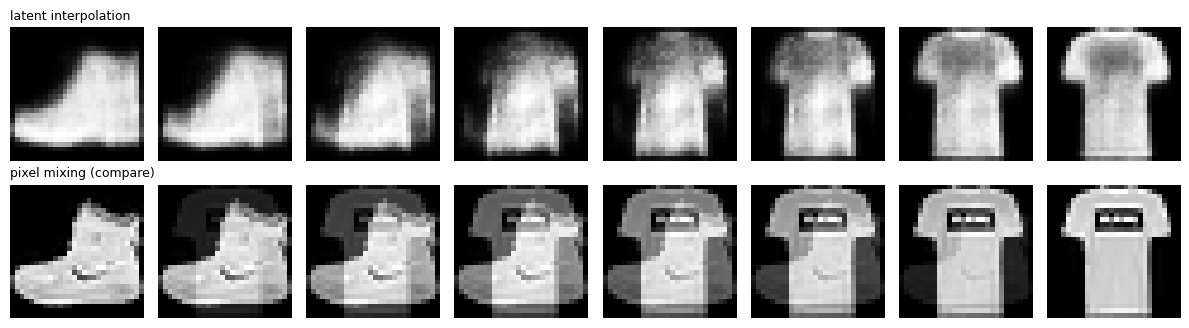

In [12]:
# 셀 2. 잠재 공간 보간 - 신발과 티셔츠 '사이'
# 두 이미지를 잠재 벡터로 압축한 뒤, 두 벡터 '사이의 점'들을 디코더로 복원하면 픽셀 섞기와는 전혀 다른 일이 벌어진다

model.eval()
idx_a = next(i for i, (_, y) in enumerate(train_data) if y== 9) # 신발
idx_b = next(i for i, (_, y) in enumerate(train_data) if y== 0) # 티셔츠
img_a = train_data[idx_a][0].unsqueeze(0).to(device) # 이미지 가져오기
img_b = train_data[idx_b][0].unsqueeze(0).to(device) # (1,28,28) → (1,1,28,28) 배치차원 추가

with torch.no_grad():
  z_a, z_b = model.encoder(img_a), model.encoder(img_b) # 두 이미지를 잠재 벡터로 압축
  steps = 8
  fig, axes = plt.subplots(2, steps, figsize=(12, 3.4))
  for i in range(steps):
    t = i / (steps-1) #
    # 잠재 공간 보간
    # 잠재 공간 보간이 하나의 객체(신발)에서 다른 객체(티셔츠)로 부드럽게 전환되는 의미있는 중간 형태를 생성하여
    # 오토인코더가 의미론적 표현을 학습하는 능력을 보여준다
    z_mix = (1-t) * z_a + t * z_b # 가중 평균 - 특정 데이터가
    img_z = model.decoder(z_mix).reshape(28,28).cpu()
    axes[0, i].imshow(img_z, cmap="gray")
    axes[0, i].axis("off")

    # 비교용 - 그냥 픽셀 섞기
    img_p = ((1-t) * img_a + t * img_b)[0,0].cpu()
    axes[1, i].imshow(img_p, cmap="gray"); axes[1, i].axis("off")

axes[0,0].set_title("latent interpolation", loc="left", fontsize=9)
axes[1,0].set_title("pixel mixing (compare)", loc="left", fontsize=9)
plt.tight_layout()
plt.savefig("plot1_interpolation.png")
plt.show()

# 잠재 공간은 '의미의 지도'다 - 지도 위를 걸으면 중간마다 그럴듯한 이미지가 존재한다.
# 생성 모델 - 이 지도(잠재 공간)를 잘 만들고 지도 위의 아무 점이나 이미지로 바꾸는 기술